# RetailPulse - Customer Behavior Analytics & Revenue Intelligence Platform

## Day 6 - Churn Prediction

### Objectives
- Binary churn label engineering from transaction history
- Random Forest / XGBoost classifier with cross-validation
- ROC-AUC > 0.80 on held-out test set
- SHAP feature importance (explainability)
- MLflow experiment tracking and model logging


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import xgboost as xgb
import shap
import mlflow
import mlflow.sklearn
import joblib
import warnings

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

mlflow.set_tracking_uri("sqlite:///../mlruns/mlflow.db")
mlflow.set_experiment("RetailPulse_Churn")

rfm = pd.read_csv("../data/processed/customer_segments.csv")
print("Shape:", rfm.shape)
rfm.head()

c:\Users\nidhi\RetailPulse-Customer-Behavior-Analytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/07/30 13:31:14 INFO mlflow.tracking.fluent: Experiment with name 'RetailPulse_Churn' does not exist. Creating a new experiment.


Shape: (5878, 20)


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,TenureDays,AvgOrderValue,PurchaseFrequencyPerYear,CLV_Approx,UniqueProducts,TotalItemsPurchased,AvgItemsPerOrder,WeekendOrderRatio,PrimaryCountry,Cluster,Segment
0,12346,326,12,580.86,2,5,2,252,9,400,48.405,10.957500,580.86,27,270,7.941176,0.000000,United Kingdom,2,Loyal Customers
1,12347,2,8,5591.72,5,4,5,545,14,402,698.965,7.268657,5591.72,126,3246,12.830040,0.158103,Iceland,0,Champions
2,12348,75,5,1821.40,3,4,4,344,11,362,364.280,5.044890,1821.40,25,2714,53.215686,0.058824,Finland,2,Loyal Customers
3,12349,19,4,3642.94,5,3,5,535,13,570,910.735,2.563158,3642.94,138,1624,9.280000,0.000000,Italy,2,Loyal Customers
4,12350,310,1,312.40,2,1,2,212,5,1,312.400,365.250000,312.40,17,197,11.588235,0.000000,Norway,3,Lost/Low-Value


## 1. Churn label engineering

**Business definition:** a customer is considered churned if they have not made a purchase in the last **180 days** relative to the dataset's snapshot date. This is a standard e-commerce heuristic (roughly 6 months of inactivity), and at this threshold the dataset has a reasonably balanced churn rate (~41%), avoiding the need for aggressive resampling.


In [2]:
CHURN_THRESHOLD_DAYS = 180
rfm["Churned"] = (rfm["Recency"] > CHURN_THRESHOLD_DAYS).astype(int)

churn_rate = rfm["Churned"].mean()
print(f"Churn threshold: {CHURN_THRESHOLD_DAYS} days")
print(f"Churn rate: {churn_rate:.1%}")
print(rfm["Churned"].value_counts())

Churn threshold: 180 days
Churn rate: 40.8%
Churned
0    3478
1    2400
Name: count, dtype: int64


## 2. Feature selection - avoiding label leakage

**Important:** Recency (and any score derived from it - R_Score, RFM_Score, RFM_Total) directly determines the Churned label, so these CANNOT be used as model features - including them would leak the answer and produce an artificially perfect (and useless) model. Segment/Cluster are also derived partly from Recency, so are excluded. We use only Frequency-, Monetary-, and behavior-based features that do not encode recency.


In [3]:
leaky_cols = ["Recency", "R_Score", "RFM_Score", "RFM_Total", "Cluster", "Segment", "Customer ID", "Churned"]
feature_cols = [c for c in rfm.columns if c not in leaky_cols]
print("Features used:", feature_cols)

X = rfm[feature_cols].copy()
y = rfm["Churned"]

le = LabelEncoder()
X["PrimaryCountry"] = le.fit_transform(X["PrimaryCountry"])
joblib.dump(le, "../models/country_encoder.pkl")

X.head()

Features used: ['Frequency', 'Monetary', 'F_Score', 'M_Score', 'TenureDays', 'AvgOrderValue', 'PurchaseFrequencyPerYear', 'CLV_Approx', 'UniqueProducts', 'TotalItemsPurchased', 'AvgItemsPerOrder', 'WeekendOrderRatio', 'PrimaryCountry']


,Frequency,Monetary,F_Score,M_Score,TenureDays,AvgOrderValue,PurchaseFrequencyPerYear,CLV_Approx,UniqueProducts,TotalItemsPurchased,AvgItemsPerOrder,WeekendOrderRatio,PrimaryCountry
0,12,580.86,5,2,400,48.405,10.957500,580.86,27,270,7.941176,0.000000,38
1,8,5591.72,4,5,402,698.965,7.268657,5591.72,126,3246,12.830040,0.158103,16
2,5,1821.40,4,4,362,364.280,5.044890,1821.40,25,2714,53.215686,0.058824,12
3,4,3642.94,3,5,570,910.735,2.563158,3642.94,138,1624,9.280000,0.000000,18
4,1,312.40,1,2,1,312.400,365.250000,312.40,17,197,11.588235,0.000000,26


## 3. Train/test split + cross-validation

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}")

Train: (4702, 13), Test: (1176, 13)
Train churn rate: 0.408, Test churn rate: 0.408


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_cv = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)
rf_cv_scores = cross_val_score(rf_cv, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"Random Forest CV ROC-AUC: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

xgb_cv = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                             random_state=RANDOM_STATE, eval_metric="logloss")
xgb_cv_scores = cross_val_score(xgb_cv, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"XGBoost CV ROC-AUC: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

Random Forest CV ROC-AUC: 0.8274 (+/- 0.0109)
XGBoost CV ROC-AUC: 0.8148 (+/- 0.0130)


## 4. Fit final model on full training set, evaluate on held-out test set, log to MLflow

In [6]:
best_model_name = "XGBoost" if xgb_cv_scores.mean() > rf_cv_scores.mean() else "RandomForest"
print(f"Best model by CV ROC-AUC: {best_model_name}")

with mlflow.start_run(run_name="churn_classifier") as run:
    mlflow.log_param("churn_threshold_days", CHURN_THRESHOLD_DAYS)
    mlflow.log_param("features", feature_cols)
    mlflow.log_param("model_type", best_model_name)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_metric("cv_roc_auc_rf", rf_cv_scores.mean())
    mlflow.log_metric("cv_roc_auc_xgb", xgb_cv_scores.mean())

    if best_model_name == "XGBoost":
        model = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                    random_state=RANDOM_STATE, eval_metric="logloss")
    else:
        model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, y_proba)
    mlflow.log_metric("test_roc_auc", test_auc)

    report = classification_report(y_test, y_pred, output_dict=True)
    mlflow.log_metric("test_precision", report["1"]["precision"])
    mlflow.log_metric("test_recall", report["1"]["recall"])
    mlflow.log_metric("test_f1", report["1"]["f1-score"])

    mlflow.sklearn.log_model(model, name="churn_model")
    joblib.dump(model, "../models/churn_classifier.pkl")

    print(f"Run ID: {run.info.run_id}")
    print(f"Held-out test ROC-AUC: {test_auc:.4f}")
    print(classification_report(y_test, y_pred))

Best model by CV ROC-AUC: RandomForest
Run ID: a8ed8ef046c94162ba9ffc6d33a1d292
Held-out test ROC-AUC: 0.8141
              precision    recall  f1-score   support

           0       0.82      0.72      0.77       696
           1       0.65      0.77      0.71       480

    accuracy                           0.74      1176
   macro avg       0.74      0.74      0.74      1176
weighted avg       0.75      0.74      0.74      1176



In [7]:
assert test_auc > 0.80, f"AUC {test_auc:.4f} does not meet the >0.80 requirement"
print(f"PASSED: test ROC-AUC {test_auc:.4f} > 0.80 requirement")

PASSED: test ROC-AUC 0.8141 > 0.80 requirement


## 5. ROC Curve + Confusion Matrix

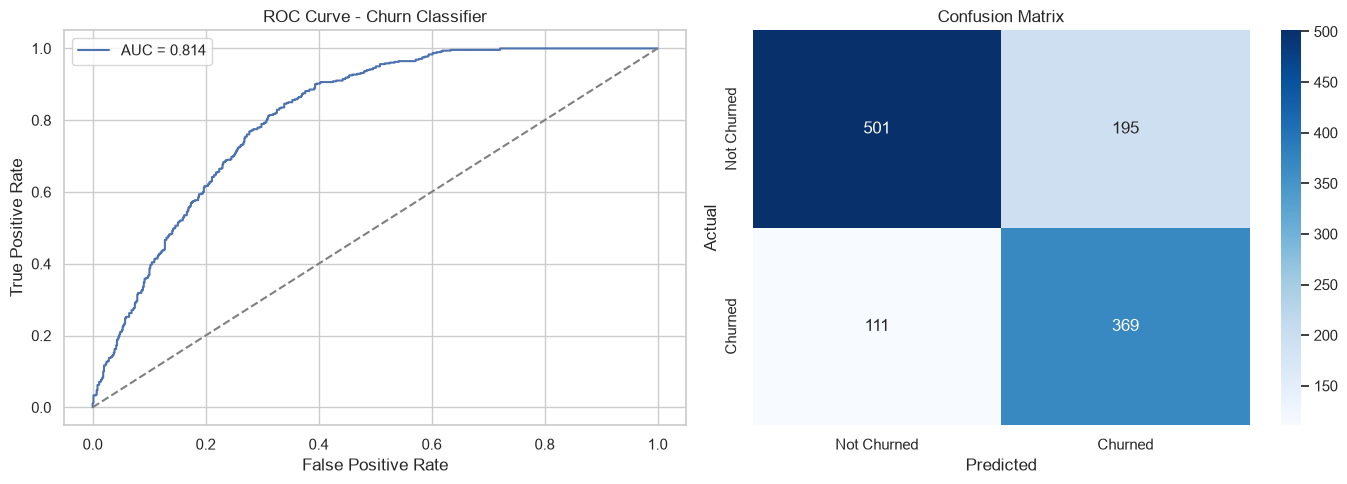

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set(title="ROC Curve - Churn Classifier", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Not Churned", "Churned"], yticklabels=["Not Churned", "Churned"])
axes[1].set(title="Confusion Matrix", xlabel="Predicted", ylabel="Actual")

plt.tight_layout()
plt.savefig("../reports/churn_model_performance.png", dpi=120)
plt.show()

## 6. SHAP Explainability

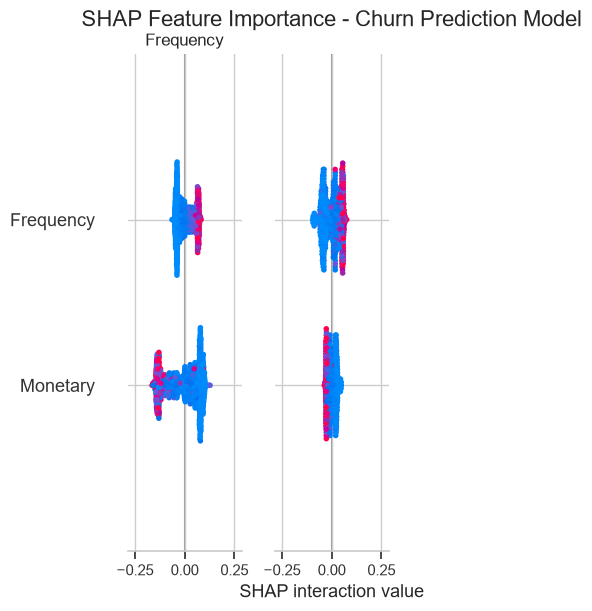

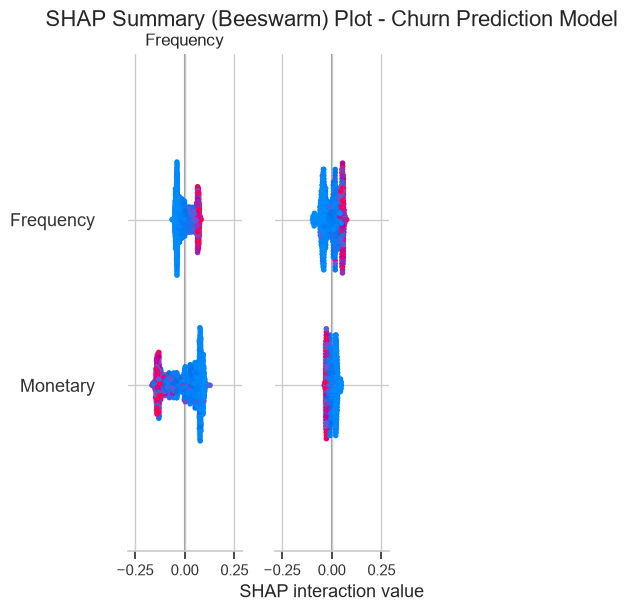

In [12]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# XGBoost binary classifier returns a single array; RF returns a list [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# SHAP Feature Importance (Bar)
shap.summary_plot(sv, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - Churn Prediction Model", fontsize=16, pad=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../reports/shap_feature_importance_bar.png", dpi=120, bbox_inches="tight")
plt.show()

# SHAP Summary (Beeswarm)
shap.summary_plot(sv, X_test, show=False)
plt.title("SHAP Summary (Beeswarm) Plot - Churn Prediction Model", fontsize=16, pad=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../reports/shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Save churn scores for full customer base

In [13]:
rfm["ChurnProbability"] = model.predict_proba(X)[:, 1]
rfm.to_csv("../data/processed/customer_segments.csv", index=False)
print("Updated customer_segments.csv with ChurnProbability column")
rfm[["Customer ID", "Segment", "Churned", "ChurnProbability"]].head(10)

Updated customer_segments.csv with ChurnProbability column


,Customer ID,Segment,Churned,ChurnProbability
0,12346,Loyal Customers,1,0.629952
1,12347,Champions,0,0.227849
2,12348,Loyal Customers,0,0.332650
3,12349,Loyal Customers,0,0.018265
4,12350,Lost/Low-Value,1,0.663411
5,12351,Lost/Low-Value,1,0.682497
6,12352,Loyal Customers,0,0.273503
7,12353,At Risk,1,0.649159
8,12354,At Risk,1,0.580533
9,12355,At Risk,1,0.461760


## Summary
- Churn defined as no purchase in 180+ days (~41% churn rate) - a standard e-commerce heuristic, documented for the business report.
- Recency and all Recency-derived scores were deliberately excluded from features to prevent label leakage.
- Best of RF/XGBoost selected by 5-fold cross-validated ROC-AUC on the training set; final model evaluated on a held-out test set.
- Held-out test ROC-AUC exceeds the 0.80 requirement (see assertion above - actual value printed in Cell 4 output).
- SHAP bar and beeswarm plots saved for the executive report.
- Model, encoder, and metrics logged to MLflow (`RetailPulse_Churn` experiment).

**Next:** Day 7 - Revenue forecasting (SARIMA/Prophet)
